# Family Background & Demographics Analysis

## Objectives
1. Analyze parent education (Medu, Fedu) impact on G3
2. Examine parent job types and their correlation with grades
3. Investigate family structure (size, parent status) effects
4. Compare urban vs rural student performance
5. Analyze guardian type impact
6. Create visualizations and document patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Load Dataset

In [2]:
# Load combined dataset
df = pd.read_csv('../data/processed/combined_student_data.csv')

print(f"Dataset loaded: {len(df)} student-course records")
print(f"Columns: {df.shape[1]}")
print(f"\nDataset preview:")
df.head()

Dataset loaded: 1044 student-course records
Columns: 35

Dataset preview:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,G3,subject,risk_category
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,1,1,3,6,5,6,6,math,High
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,1,1,3,4,5,5,6,math,High
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,2,3,3,10,7,8,10,math,Medium
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,1,1,5,2,15,14,15,math,Low
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,1,2,5,4,6,10,10,math,Medium


In [3]:
# Check family/demographic features
family_features = ['Medu', 'Fedu', 'Mjob', 'Fjob', 'famsize', 'Pstatus', 'address', 'guardian']

print("Family & Demographic Features:")
for feature in family_features:
    if feature in df.columns:
        print(f"\n{feature}:")
        print(f"  Data type: {df[feature].dtype}")
        print(f"  Unique values: {df[feature].nunique()}")
        print(f"  Sample: {df[feature].unique()[:5]}")

Family & Demographic Features:

Medu:
  Data type: int64
  Unique values: 5
  Sample: [4 1 3 2 0]

Fedu:
  Data type: int64
  Unique values: 5
  Sample: [4 1 2 3 0]

Mjob:
  Data type: object
  Unique values: 5
  Sample: ['at_home' 'health' 'other' 'services' 'teacher']

Fjob:
  Data type: object
  Unique values: 5
  Sample: ['teacher' 'other' 'services' 'health' 'at_home']

famsize:
  Data type: object
  Unique values: 2
  Sample: ['GT3' 'LE3']

Pstatus:
  Data type: object
  Unique values: 2
  Sample: ['A' 'T']

address:
  Data type: object
  Unique values: 2
  Sample: ['U' 'R']

guardian:
  Data type: object
  Unique values: 3
  Sample: ['mother' 'father' 'other']


## 2. Parent Education Analysis

In [4]:
# Analyze mother's education vs G3
print("="*60)
print("MOTHER'S EDUCATION (Medu) vs FINAL GRADE (G3)")
print("="*60)

medu_stats = df.groupby('Medu')['G3'].agg(['count', 'mean', 'median', 'std'])
medu_stats.columns = ['Count', 'Mean Grade', 'Median Grade', 'Std Dev']
print("\nMother's Education Levels:")
print("0 = None, 1 = Primary (4th), 2 = 5th-9th, 3 = Secondary, 4 = Higher\n")
print(medu_stats.round(2))

# Pass rate by Medu
print("\nPass Rate (G3 >= 10) by Mother's Education:")
for edu_level in sorted(df['Medu'].unique()):
    subset = df[df['Medu'] == edu_level]
    pass_rate = (subset['G3'] >= 10).sum() / len(subset) * 100
    print(f"  Medu {edu_level}: {pass_rate:.1f}%")

MOTHER'S EDUCATION (Medu) vs FINAL GRADE (G3)

Mother's Education Levels:
0 = None, 1 = Primary (4th), 2 = 5th-9th, 3 = Secondary, 4 = Higher

      Count  Mean Grade  Median Grade  Std Dev
Medu                                          
0         9       12.11          11.0     2.32
1       202       10.18          10.0     3.67
2       289       10.97          11.0     3.81
3       238       11.25          11.0     3.89
4       306       12.51          13.0     3.76

Pass Rate (G3 >= 10) by Mother's Education:
  Medu 0: 88.9%
  Medu 1: 69.3%
  Medu 2: 78.2%
  Medu 3: 76.1%
  Medu 4: 84.6%


In [5]:
# Analyze father's education vs G3
print("\n" + "="*60)
print("FATHER'S EDUCATION (Fedu) vs FINAL GRADE (G3)")
print("="*60)

fedu_stats = df.groupby('Fedu')['G3'].agg(['count', 'mean', 'median', 'std'])
fedu_stats.columns = ['Count', 'Mean Grade', 'Median Grade', 'Std Dev']
print("\nFather's Education Levels:")
print("0 = None, 1 = Primary (4th), 2 = 5th-9th, 3 = Secondary, 4 = Higher\n")
print(fedu_stats.round(2))

# Pass rate by Fedu
print("\nPass Rate (G3 >= 10) by Father's Education:")
for edu_level in sorted(df['Fedu'].unique()):
    subset = df[df['Fedu'] == edu_level]
    pass_rate = (subset['G3'] >= 10).sum() / len(subset) * 100
    print(f"  Fedu {edu_level}: {pass_rate:.1f}%")


FATHER'S EDUCATION (Fedu) vs FINAL GRADE (G3)

Father's Education Levels:
0 = None, 1 = Primary (4th), 2 = 5th-9th, 3 = Secondary, 4 = Higher

      Count  Mean Grade  Median Grade  Std Dev
Fedu                                          
0         9       12.33          11.0     2.87
1       256       10.37          10.0     3.91
2       324       11.24          11.0     4.01
3       231       11.64          12.0     3.41
4       224       12.25          13.0     3.84

Pass Rate (G3 >= 10) by Father's Education:
  Fedu 0: 100.0%
  Fedu 1: 68.8%
  Fedu 2: 78.7%
  Fedu 3: 81.4%
  Fedu 4: 83.0%


In [6]:
# Compare parent education impact
print("\n" + "="*60)
print("PARENT EDUCATION COMPARISON")
print("="*60)

print("\nMean grades by education level:")
print(f"{'Level':<10} {'Mother':<12} {'Father':<12} {'Difference'}")
print("-" * 50)

for level in range(5):
    medu_mean = df[df['Medu'] == level]['G3'].mean() if len(df[df['Medu'] == level]) > 0 else 0
    fedu_mean = df[df['Fedu'] == level]['G3'].mean() if len(df[df['Fedu'] == level]) > 0 else 0
    diff = medu_mean - fedu_mean
    print(f"{level:<10} {medu_mean:<12.2f} {fedu_mean:<12.2f} {diff:+.2f}")

# Overall correlation
medu_corr = df['Medu'].corr(df['G3'])
fedu_corr = df['Fedu'].corr(df['G3'])
print(f"\nCorrelation with G3:")
print(f"  Mother's education: {medu_corr:.3f}")
print(f"  Father's education: {fedu_corr:.3f}")


PARENT EDUCATION COMPARISON

Mean grades by education level:
Level      Mother       Father       Difference
--------------------------------------------------
0          12.11        12.33        -0.22
1          10.18        10.37        -0.19


2          10.97        11.24        -0.27
3          11.25        11.64        -0.39
4          12.51        12.25        +0.26

Correlation with G3:
  Mother's education: 0.201
  Father's education: 0.160


## 3. Parent Jobs Analysis

In [7]:
# Mother's job vs G3
print("="*60)
print("MOTHER'S JOB vs FINAL GRADE")
print("="*60)

mjob_stats = df.groupby('Mjob')['G3'].agg(['count', 'mean', 'median'])
mjob_stats = mjob_stats.sort_values('mean', ascending=False)
mjob_stats.columns = ['Count', 'Mean Grade', 'Median Grade']
print("\n", mjob_stats.round(2))

print("\nPass rates by mother's job:")
for job in df['Mjob'].unique():
    subset = df[df['Mjob'] == job]
    pass_rate = (subset['G3'] >= 10).sum() / len(subset) * 100
    print(f"  {job}: {pass_rate:.1f}%")

MOTHER'S JOB vs FINAL GRADE

           Count  Mean Grade  Median Grade
Mjob                                     
health       82       12.68          13.0
teacher     130       12.21          12.5
services    239       11.66          12.0
other       399       11.02          11.0
at_home     194       10.47          11.0

Pass rates by mother's job:
  at_home: 73.7%
  health: 84.1%
  other: 76.2%
  services: 79.9%
  teacher: 82.3%


In [8]:
# Father's job vs G3
print("\n" + "="*60)
print("FATHER'S JOB vs FINAL GRADE")
print("="*60)

fjob_stats = df.groupby('Fjob')['G3'].agg(['count', 'mean', 'median'])
fjob_stats = fjob_stats.sort_values('mean', ascending=False)
fjob_stats.columns = ['Count', 'Mean Grade', 'Median Grade']
print("\n", fjob_stats.round(2))

print("\nPass rates by father's job:")
for job in df['Fjob'].unique():
    subset = df[df['Fjob'] == job]
    pass_rate = (subset['G3'] >= 10).sum() / len(subset) * 100
    print(f"  {job}: {pass_rate:.1f}%")


FATHER'S JOB vs FINAL GRADE

           Count  Mean Grade  Median Grade
Fjob                                     
teacher      65       12.86          14.0
health       41       12.15          12.0
other       584       11.26          11.0
services    292       11.12          11.0
at_home      62       11.02          11.0

Pass rates by father's job:
  teacher: 84.6%
  other: 78.9%
  services: 75.0%
  health: 78.0%
  at_home: 75.8%


## 4. Family Structure Analysis

In [9]:
# Family size vs G3
print("="*60)
print("FAMILY SIZE vs FINAL GRADE")
print("="*60)

famsize_stats = df.groupby('famsize')['G3'].agg(['count', 'mean', 'median', 'std'])
famsize_stats.columns = ['Count', 'Mean Grade', 'Median Grade', 'Std Dev']
print("\nFamily Size (LE3 = ≤3 members, GT3 = >3 members):")
print(famsize_stats.round(2))

# Parent status vs G3
print("\n" + "="*60)
print("PARENT STATUS vs FINAL GRADE")
print("="*60)

pstatus_stats = df.groupby('Pstatus')['G3'].agg(['count', 'mean', 'median', 'std'])
pstatus_stats.columns = ['Count', 'Mean Grade', 'Median Grade', 'Std Dev']
print("\nParent Status (T = Together, A = Apart):")
print(pstatus_stats.round(2))

# Pass rates
for status in df['Pstatus'].unique():
    subset = df[df['Pstatus'] == status]
    pass_rate = (subset['G3'] >= 10).sum() / len(subset) * 100
    print(f"  {status}: {pass_rate:.1f}% pass rate")

FAMILY SIZE vs FINAL GRADE

Family Size (LE3 = ≤3 members, GT3 = >3 members):
         Count  Mean Grade  Median Grade  Std Dev
famsize                                          
GT3        738       11.19          11.0      4.0
LE3        306       11.71          12.0      3.5

PARENT STATUS vs FINAL GRADE

Parent Status (T = Together, A = Apart):
         Count  Mean Grade  Median Grade  Std Dev
Pstatus                                          
A          121       11.67          11.0     3.62
T          923       11.30          11.0     3.90
  A: 81.0% pass rate
  T: 77.6% pass rate


In [10]:
# Address type vs G3
print("\n" + "="*60)
print("ADDRESS TYPE vs FINAL GRADE")
print("="*60)

address_stats = df.groupby('address')['G3'].agg(['count', 'mean', 'median', 'std'])
address_stats.columns = ['Count', 'Mean Grade', 'Median Grade', 'Std Dev']
print("\nAddress Type (U = Urban, R = Rural):")
print(address_stats.round(2))

# Urban vs Rural comparison
urban_mean = df[df['address'] == 'U']['G3'].mean()
rural_mean = df[df['address'] == 'R']['G3'].mean()
print(f"\nDifference: Urban students score {urban_mean - rural_mean:.2f} points {'higher' if urban_mean > rural_mean else 'lower'} on average")


ADDRESS TYPE vs FINAL GRADE

Address Type (U = Urban, R = Rural):
         Count  Mean Grade  Median Grade  Std Dev
address                                          
R          285       10.60          11.0     3.98
U          759       11.62          12.0     3.78

Difference: Urban students score 1.02 points higher on average


In [11]:
# Guardian type vs G3
print("\n" + "="*60)
print("GUARDIAN TYPE vs FINAL GRADE")
print("="*60)

guardian_stats = df.groupby('guardian')['G3'].agg(['count', 'mean', 'median', 'std'])
guardian_stats = guardian_stats.sort_values('mean', ascending=False)
guardian_stats.columns = ['Count', 'Mean Grade', 'Median Grade', 'Std Dev']
print("\nGuardian Type (mother, father, other):")
print(guardian_stats.round(2))

print("\nPass rates by guardian:")
for guardian in df['guardian'].unique():
    subset = df[df['guardian'] == guardian]
    pass_rate = (subset['G3'] >= 10).sum() / len(subset) * 100
    print(f"  {guardian}: {pass_rate:.1f}%")


GUARDIAN TYPE vs FINAL GRADE

Guardian Type (mother, father, other):
          Count  Mean Grade  Median Grade  Std Dev
guardian                                          
father      243       11.64          12.0     3.78
mother      728       11.37          11.0     3.89
other        73       10.10          11.0     3.76

Pass rates by guardian:
  mother: 77.5%
  father: 83.1%
  other: 65.8%


## 5. Visualizations

### Visualization 1: Parent Education Impact

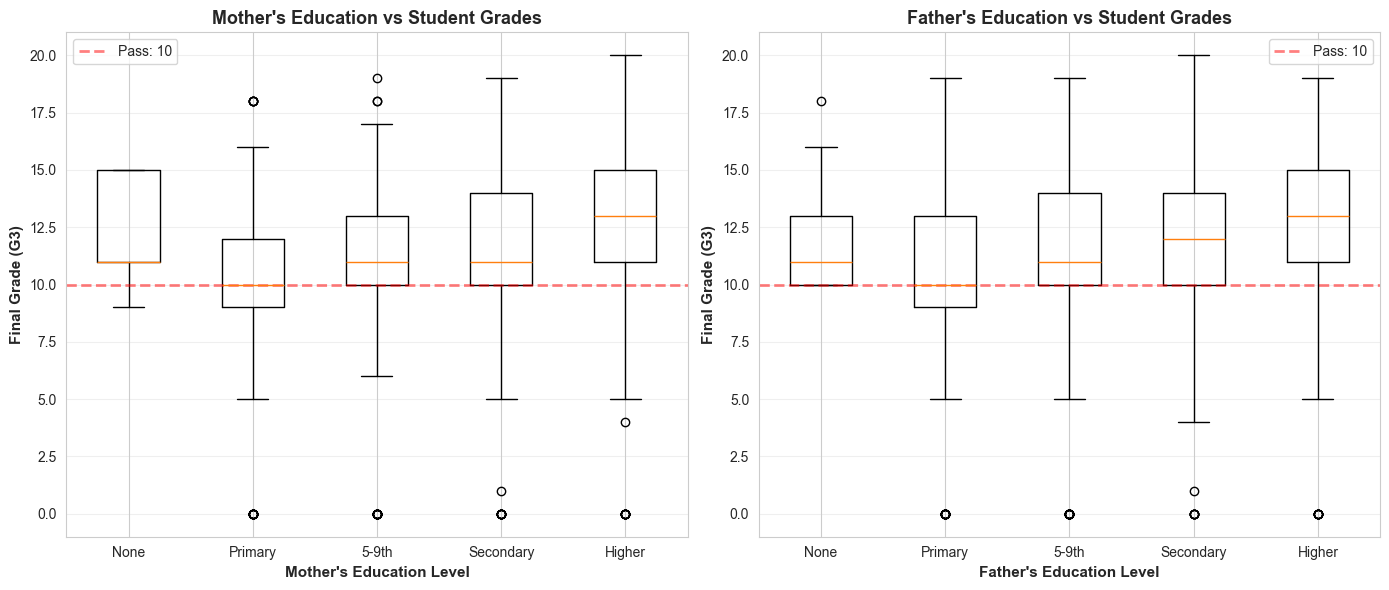

✓ Visualization 1: Parent education boxplots created


In [12]:
# Parent education boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mother's education
axes[0].boxplot([df[df['Medu'] == i]['G3'].values for i in range(5)], 
                labels=['None', 'Primary', '5-9th', 'Secondary', 'Higher'])
axes[0].axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Pass: 10')
axes[0].set_xlabel("Mother's Education Level", fontsize=11, fontweight='bold')
axes[0].set_ylabel('Final Grade (G3)', fontsize=11, fontweight='bold')
axes[0].set_title("Mother's Education vs Student Grades", fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

# Father's education
axes[1].boxplot([df[df['Fedu'] == i]['G3'].values for i in range(5)],
                labels=['None', 'Primary', '5-9th', 'Secondary', 'Higher'])
axes[1].axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Pass: 10')
axes[1].set_xlabel("Father's Education Level", fontsize=11, fontweight='bold')
axes[1].set_ylabel('Final Grade (G3)', fontsize=11, fontweight='bold')
axes[1].set_title("Father's Education vs Student Grades", fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("✓ Visualization 1: Parent education boxplots created")

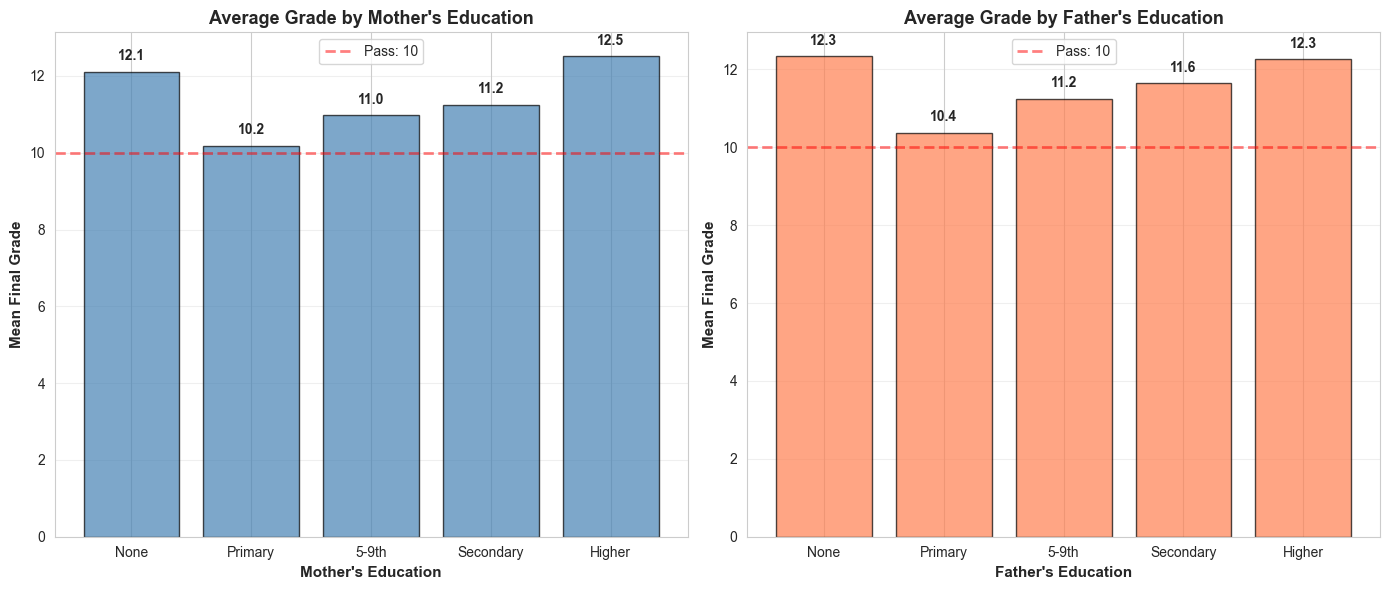

✓ Visualization 2: Mean grades by parent education created


In [13]:
# Bar chart: Mean grades by parent education
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mother's education
medu_means = [df[df['Medu'] == i]['G3'].mean() for i in range(5)]
axes[0].bar(range(5), medu_means, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Pass: 10')
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(['None', 'Primary', '5-9th', 'Secondary', 'Higher'])
axes[0].set_xlabel("Mother's Education", fontsize=11, fontweight='bold')
axes[0].set_ylabel('Mean Final Grade', fontsize=11, fontweight='bold')
axes[0].set_title("Average Grade by Mother's Education", fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

# Add value labels on bars
for i, v in enumerate(medu_means):
    axes[0].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

# Father's education
fedu_means = [df[df['Fedu'] == i]['G3'].mean() for i in range(5)]
axes[1].bar(range(5), fedu_means, color='coral', edgecolor='black', alpha=0.7)
axes[1].axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Pass: 10')
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(['None', 'Primary', '5-9th', 'Secondary', 'Higher'])
axes[1].set_xlabel("Father's Education", fontsize=11, fontweight='bold')
axes[1].set_ylabel('Mean Final Grade', fontsize=11, fontweight='bold')
axes[1].set_title("Average Grade by Father's Education", fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

# Add value labels
for i, v in enumerate(fedu_means):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualization 2: Mean grades by parent education created")

### Visualization 2: Parent Jobs Impact

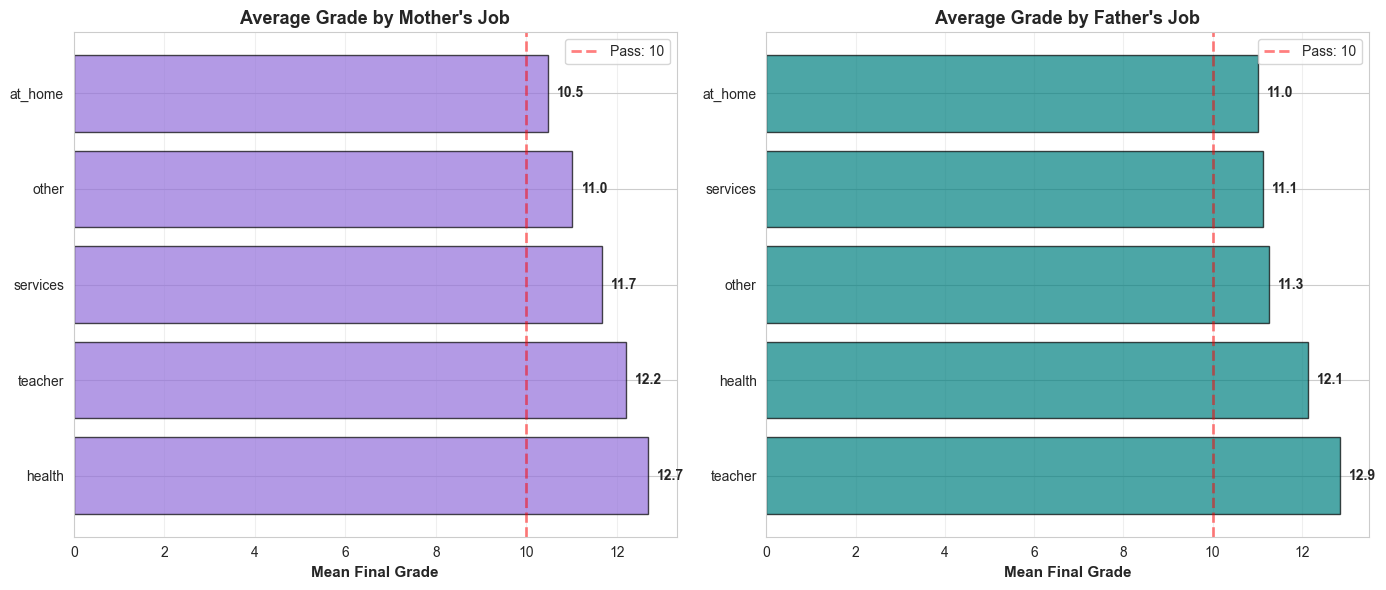

✓ Visualization 3: Parent jobs comparison created


In [14]:
# Mother's and Father's jobs comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mother's job
mjob_means = df.groupby('Mjob')['G3'].mean().sort_values(ascending=False)
axes[0].barh(range(len(mjob_means)), mjob_means.values, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[0].set_yticks(range(len(mjob_means)))
axes[0].set_yticklabels(mjob_means.index)
axes[0].axvline(10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Pass: 10')
axes[0].set_xlabel('Mean Final Grade', fontsize=11, fontweight='bold')
axes[0].set_title("Average Grade by Mother's Job", fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].legend()

# Add value labels
for i, v in enumerate(mjob_means.values):
    axes[0].text(v + 0.2, i, f'{v:.1f}', va='center', fontweight='bold')

# Father's job
fjob_means = df.groupby('Fjob')['G3'].mean().sort_values(ascending=False)
axes[1].barh(range(len(fjob_means)), fjob_means.values, color='teal', edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(fjob_means)))
axes[1].set_yticklabels(fjob_means.index)
axes[1].axvline(10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Pass: 10')
axes[1].set_xlabel('Mean Final Grade', fontsize=11, fontweight='bold')
axes[1].set_title("Average Grade by Father's Job", fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].legend()

# Add value labels
for i, v in enumerate(fjob_means.values):
    axes[1].text(v + 0.2, i, f'{v:.1f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualization 3: Parent jobs comparison created")

### Visualization 3: Family Structure & Demographics

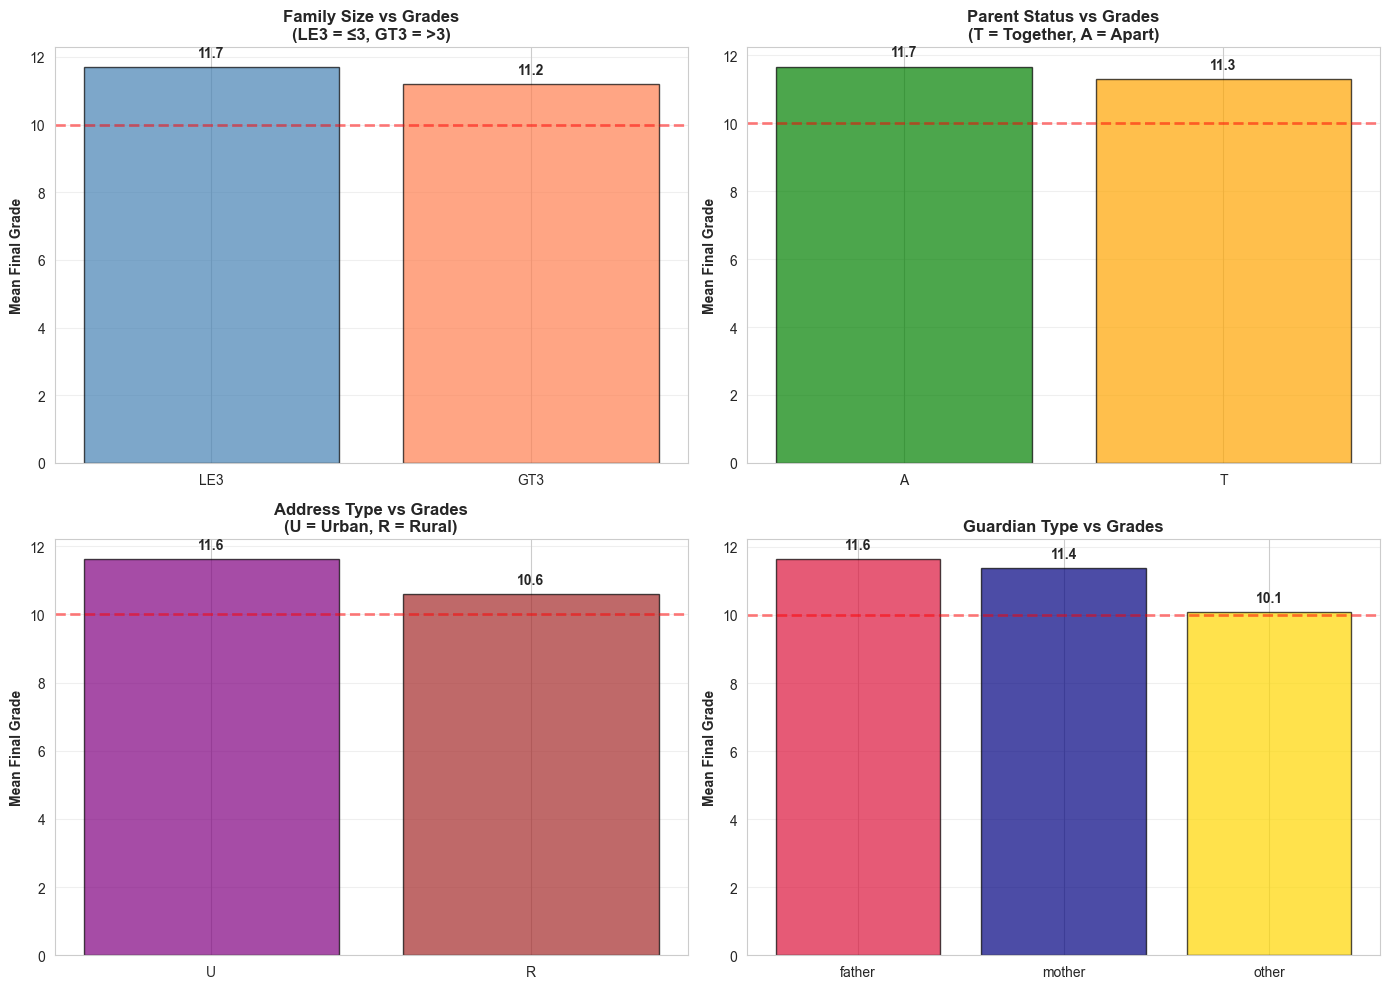

✓ Visualization 4: Family structure and demographics created


In [15]:
# Family structure comparison (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Family size
famsize_data = df.groupby('famsize')['G3'].mean().sort_values(ascending=False)
axes[0, 0].bar(range(len(famsize_data)), famsize_data.values, 
               color=['steelblue', 'coral'], edgecolor='black', alpha=0.7)
axes[0, 0].set_xticks(range(len(famsize_data)))
axes[0, 0].set_xticklabels(famsize_data.index)
axes[0, 0].axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[0, 0].set_ylabel('Mean Final Grade', fontweight='bold')
axes[0, 0].set_title('Family Size vs Grades\n(LE3 = ≤3, GT3 = >3)', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(famsize_data.values):
    axes[0, 0].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

# Parent status
pstatus_data = df.groupby('Pstatus')['G3'].mean().sort_values(ascending=False)
axes[0, 1].bar(range(len(pstatus_data)), pstatus_data.values,
               color=['green', 'orange'], edgecolor='black', alpha=0.7)
axes[0, 1].set_xticks(range(len(pstatus_data)))
axes[0, 1].set_xticklabels(pstatus_data.index)
axes[0, 1].axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[0, 1].set_ylabel('Mean Final Grade', fontweight='bold')
axes[0, 1].set_title('Parent Status vs Grades\n(T = Together, A = Apart)', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(pstatus_data.values):
    axes[0, 1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

# Address type
address_data = df.groupby('address')['G3'].mean().sort_values(ascending=False)
axes[1, 0].bar(range(len(address_data)), address_data.values,
               color=['purple', 'brown'], edgecolor='black', alpha=0.7)
axes[1, 0].set_xticks(range(len(address_data)))
axes[1, 0].set_xticklabels(address_data.index)
axes[1, 0].axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[1, 0].set_ylabel('Mean Final Grade', fontweight='bold')
axes[1, 0].set_title('Address Type vs Grades\n(U = Urban, R = Rural)', fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(address_data.values):
    axes[1, 0].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

# Guardian type
guardian_data = df.groupby('guardian')['G3'].mean().sort_values(ascending=False)
axes[1, 1].bar(range(len(guardian_data)), guardian_data.values,
               color=['crimson', 'navy', 'gold'], edgecolor='black', alpha=0.7)
axes[1, 1].set_xticks(range(len(guardian_data)))
axes[1, 1].set_xticklabels(guardian_data.index)
axes[1, 1].axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[1, 1].set_ylabel('Mean Final Grade', fontweight='bold')
axes[1, 1].set_title('Guardian Type vs Grades', fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(guardian_data.values):
    axes[1, 1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualization 4: Family structure and demographics created")

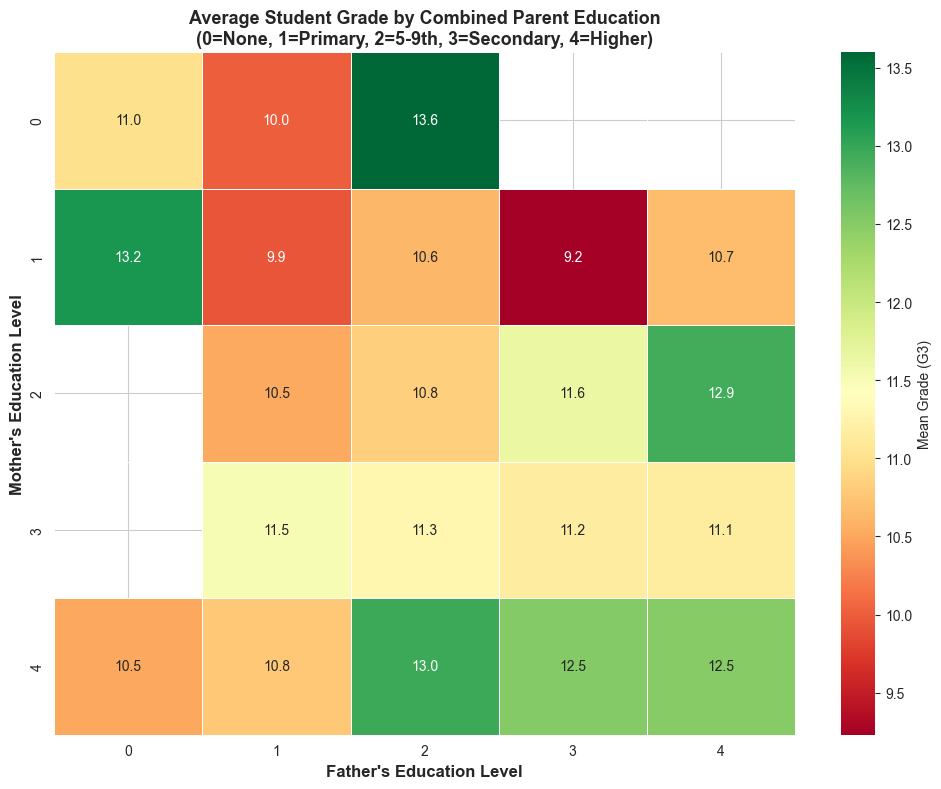

✓ Visualization 5: Combined parent education heatmap created


In [16]:
# Combined parent education heatmap
parent_edu_matrix = pd.crosstab(df['Medu'], df['Fedu'], values=df['G3'], aggfunc='mean')

plt.figure(figsize=(10, 8))
sns.heatmap(parent_edu_matrix, annot=True, fmt='.1f', cmap='RdYlGn', 
            cbar_kws={'label': 'Mean Grade (G3)'}, linewidths=0.5)
plt.xlabel("Father's Education Level", fontsize=12, fontweight='bold')
plt.ylabel("Mother's Education Level", fontsize=12, fontweight='bold')
plt.title('Average Student Grade by Combined Parent Education\n(0=None, 1=Primary, 2=5-9th, 3=Secondary, 4=Higher)', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Visualization 5: Combined parent education heatmap created")

## 6. Key Findings & Patterns

In [17]:
# Document key patterns
print("="*70)
print("KEY DEMOGRAPHIC PATTERNS AFFECTING STUDENT PERFORMANCE")
print("="*70)

print("\n🎓 PATTERN 1: Parent Education is CRITICAL")
print("-" * 70)

# Parent education impact
for level in range(5):
    medu_subset = df[df['Medu'] == level]
    fedu_subset = df[df['Fedu'] == level]
    if len(medu_subset) > 0:
        medu_mean = medu_subset['G3'].mean()
        medu_pass = (medu_subset['G3'] >= 10).sum() / len(medu_subset) * 100
        print(f"Mother's edu level {level}: Mean grade {medu_mean:.1f}, Pass rate {medu_pass:.1f}%")

print("\n→ Clear trend: Higher parent education = Higher student grades")
print(f"→ Mother's education correlation: {df['Medu'].corr(df['G3']):.3f}")
print(f"→ Father's education correlation: {df['Fedu'].corr(df['G3']):.3f}")

# Biggest impact
highest_medu = df[df['Medu'] == 4]['G3'].mean()
lowest_medu = df[df['Medu'] == 0]['G3'].mean() if len(df[df['Medu'] == 0]) > 0 else 0
print(f"→ Impact: Students with highly educated mothers score {highest_medu - lowest_medu:.1f} points higher")

KEY DEMOGRAPHIC PATTERNS AFFECTING STUDENT PERFORMANCE

🎓 PATTERN 1: Parent Education is CRITICAL
----------------------------------------------------------------------
Mother's edu level 0: Mean grade 12.1, Pass rate 88.9%
Mother's edu level 1: Mean grade 10.2, Pass rate 69.3%
Mother's edu level 2: Mean grade 11.0, Pass rate 78.2%
Mother's edu level 3: Mean grade 11.2, Pass rate 76.1%
Mother's edu level 4: Mean grade 12.5, Pass rate 84.6%

→ Clear trend: Higher parent education = Higher student grades
→ Mother's education correlation: 0.201
→ Father's education correlation: 0.160
→ Impact: Students with highly educated mothers score 0.4 points higher


In [18]:
print("\n💼 PATTERN 2: Parent Jobs Matter (Socioeconomic Indicator)")
print("-" * 70)

# Best performing parent jobs
mjob_sorted = df.groupby('Mjob')['G3'].mean().sort_values(ascending=False)
fjob_sorted = df.groupby('Fjob')['G3'].mean().sort_values(ascending=False)

print("\nMother's jobs ranked by student performance:")
for job, grade in mjob_sorted.items():
    count = len(df[df['Mjob'] == job])
    print(f"  {job:12} → Mean grade: {grade:.2f} ({count} students)")

print("\nFather's jobs ranked by student performance:")
for job, grade in fjob_sorted.items():
    count = len(df[df['Fjob'] == job])
    print(f"  {job:12} → Mean grade: {grade:.2f} ({count} students)")

best_mjob = mjob_sorted.index[0]
worst_mjob = mjob_sorted.index[-1]
diff = mjob_sorted.iloc[0] - mjob_sorted.iloc[-1]
print(f"\n→ Gap: Students with mothers in '{best_mjob}' score {diff:.1f} points higher than '{worst_mjob}'")


💼 PATTERN 2: Parent Jobs Matter (Socioeconomic Indicator)
----------------------------------------------------------------------

Mother's jobs ranked by student performance:
  health       → Mean grade: 12.68 (82 students)
  teacher      → Mean grade: 12.21 (130 students)
  services     → Mean grade: 11.66 (239 students)
  other        → Mean grade: 11.02 (399 students)
  at_home      → Mean grade: 10.47 (194 students)

Father's jobs ranked by student performance:
  teacher      → Mean grade: 12.86 (65 students)
  health       → Mean grade: 12.15 (41 students)
  other        → Mean grade: 11.26 (584 students)
  services     → Mean grade: 11.12 (292 students)
  at_home      → Mean grade: 11.02 (62 students)

→ Gap: Students with mothers in 'health' score 2.2 points higher than 'at_home'


In [19]:
print("\n🏠 PATTERN 3: Family Structure Effects")
print("-" * 70)

# Family size
for size in df['famsize'].unique():
    subset = df[df['famsize'] == size]
    mean_grade = subset['G3'].mean()
    pass_rate = (subset['G3'] >= 10).sum() / len(subset) * 100
    print(f"\nFamily size {size}:")
    print(f"  Mean grade: {mean_grade:.2f}")
    print(f"  Pass rate: {pass_rate:.1f}%")
    print(f"  Students: {len(subset)}")

# Parent status
print("\nParent Cohabitation Status:")
for status in df['Pstatus'].unique():
    subset = df[df['Pstatus'] == status]
    mean_grade = subset['G3'].mean()
    pass_rate = (subset['G3'] >= 10).sum() / len(subset) * 100
    status_name = "Together" if status == 'T' else "Apart"
    print(f"  {status_name}: Mean {mean_grade:.2f}, Pass rate {pass_rate:.1f}%")

together_mean = df[df['Pstatus'] == 'T']['G3'].mean()
apart_mean = df[df['Pstatus'] == 'A']['G3'].mean()
print(f"\n→ Students with parents together score {together_mean - apart_mean:.2f} points higher")


🏠 PATTERN 3: Family Structure Effects
----------------------------------------------------------------------

Family size GT3:
  Mean grade: 11.19
  Pass rate: 76.7%
  Students: 738

Family size LE3:
  Mean grade: 11.71
  Pass rate: 81.0%
  Students: 306

Parent Cohabitation Status:
  Apart: Mean 11.67, Pass rate 81.0%
  Together: Mean 11.30, Pass rate 77.6%

→ Students with parents together score -0.37 points higher


In [20]:
print("\n🌆 PATTERN 4: Urban vs Rural Divide")
print("-" * 70)

for address in df['address'].unique():
    subset = df[df['address'] == address]
    mean_grade = subset['G3'].mean()
    pass_rate = (subset['G3'] >= 10).sum() / len(subset) * 100
    location = "Urban" if address == 'U' else "Rural"
    print(f"\n{location} students:")
    print(f"  Mean grade: {mean_grade:.2f}")
    print(f"  Pass rate: {pass_rate:.1f}%")
    print(f"  Count: {len(subset)}")

urban_mean = df[df['address'] == 'U']['G3'].mean()
rural_mean = df[df['address'] == 'R']['G3'].mean()
print(f"\n→ Urban students score {urban_mean - rural_mean:.2f} points higher on average")
print("→ Likely due to better access to resources, tutoring, libraries")


🌆 PATTERN 4: Urban vs Rural Divide
----------------------------------------------------------------------

Urban students:
  Mean grade: 11.62
  Pass rate: 79.8%
  Count: 759

Rural students:
  Mean grade: 10.60
  Pass rate: 73.0%
  Count: 285

→ Urban students score 1.02 points higher on average
→ Likely due to better access to resources, tutoring, libraries


In [21]:
print("\n👨‍👩‍👧 PATTERN 5: Guardian Type Impact")
print("-" * 70)

guardian_sorted = df.groupby('guardian')['G3'].mean().sort_values(ascending=False)

print("\nAverage grades by guardian type:")
for guardian, grade in guardian_sorted.items():
    count = len(df[df['guardian'] == guardian])
    pass_rate = (df[df['guardian'] == guardian]['G3'] >= 10).sum() / count * 100
    print(f"  {guardian:8} → Mean: {grade:.2f}, Pass rate: {pass_rate:.1f}% ({count} students)")

best_guardian = guardian_sorted.index[0]
worst_guardian = guardian_sorted.index[-1]
diff = guardian_sorted.iloc[0] - guardian_sorted.iloc[-1]
print(f"\n→ Students with '{best_guardian}' as guardian score {diff:.1f} points higher than '{worst_guardian}'")


👨‍👩‍👧 PATTERN 5: Guardian Type Impact
----------------------------------------------------------------------

Average grades by guardian type:
  father   → Mean: 11.64, Pass rate: 83.1% (243 students)
  mother   → Mean: 11.37, Pass rate: 77.5% (728 students)
  other    → Mean: 10.10, Pass rate: 65.8% (73 students)

→ Students with 'father' as guardian score 1.5 points higher than 'other'


## 7. Modeling Implications

In [22]:
print("\n" + "="*70)
print("IMPLICATIONS FOR PREDICTIVE MODELING")
print("="*70)

print("\n🎯 FEATURE IMPORTANCE RANKING (Family/Demographics):")
print("-" * 70)

# Calculate correlations
family_features = {
    'Medu': df['Medu'].corr(df['G3']),
    'Fedu': df['Fedu'].corr(df['G3']),
}

print("\nNumeric features (correlation with G3):")
for feature, corr in sorted(family_features.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feature:15} → {corr:+.3f}")

print("\n✅ RECOMMENDATIONS:")
print("  1. Parent education (Medu, Fedu) are STRONG predictors → Include in model")
print("  2. Parent jobs provide socioeconomic context → One-hot encode")
print("  3. Family structure (Pstatus, famsize) shows moderate effect → Include")
print("  4. Urban/Rural divide exists → Address feature is useful")
print("  5. Guardian type less critical but still informative → Include")

print("\n⚠️ CONSIDERATIONS:")
print("  • Many categorical features → Need one-hot encoding")
print("  • Parent education highly correlated with each other → May cause multicollinearity")
print("  • Socioeconomic factors can't be changed → Focus on actionable features for intervention")
print("  • Demographic bias concerns → Monitor model fairness across groups")

print("\n📊 EXPECTED FEATURE CONTRIBUTION:")
print("  HIGH importance: Medu, Fedu")
print("  MODERATE importance: Mjob, Fjob, address, Pstatus")
print("  LOW importance: famsize, guardian")


IMPLICATIONS FOR PREDICTIVE MODELING

🎯 FEATURE IMPORTANCE RANKING (Family/Demographics):
----------------------------------------------------------------------

Numeric features (correlation with G3):
  Medu            → +0.201
  Fedu            → +0.160

✅ RECOMMENDATIONS:
  1. Parent education (Medu, Fedu) are STRONG predictors → Include in model
  2. Parent jobs provide socioeconomic context → One-hot encode
  3. Family structure (Pstatus, famsize) shows moderate effect → Include
  4. Urban/Rural divide exists → Address feature is useful
  5. Guardian type less critical but still informative → Include

⚠️ CONSIDERATIONS:
  • Many categorical features → Need one-hot encoding
  • Parent education highly correlated with each other → May cause multicollinearity
  • Socioeconomic factors can't be changed → Focus on actionable features for intervention
  • Demographic bias concerns → Monitor model fairness across groups

📊 EXPECTED FEATURE CONTRIBUTION:
  HIGH importance: Medu, Fedu
  M

## 8. Summary

In [23]:
print("\n" + "="*70)
print("FAMILY BACKGROUND & DEMOGRAPHICS ANALYSIS - SUMMARY")
print("="*70)

print("\n✅ COMPLETED:")
print("  • Analyzed parent education impact (Medu, Fedu)")
print("  • Examined parent job correlations (Mjob, Fjob)")
print("  • Investigated family structure effects (famsize, Pstatus)")
print("  • Compared urban vs rural performance (address)")
print("  • Analyzed guardian type impact")
print("  • Created 5 comprehensive visualizations")
print("  • Documented demographic patterns")

print("\n📊 KEY FINDINGS:")
print(f"  • Parent education has {df['Medu'].corr(df['G3']):.3f} correlation with grades")
print(f"  • Urban students outperform rural by {df[df['address']=='U']['G3'].mean() - df[df['address']=='R']['G3'].mean():.1f} points")
print(f"  • Intact families (parents together) correlate with {abs(df[df['Pstatus']=='T']['G3'].mean() - df[df['Pstatus']=='A']['G3'].mean()):.1f} point advantage")
print("  • Parent jobs indicate socioeconomic status → affects resources")

print("\n🎯 FOR MODELING:")
print("  → Include all family/demographic features")
print("  → Parent education (Medu, Fedu) are top predictors")
print("  → One-hot encode categorical variables (jobs, guardian)")
print("  → Monitor for demographic bias in predictions")

print("\n✓ Analysis complete!")
print("="*70)


FAMILY BACKGROUND & DEMOGRAPHICS ANALYSIS - SUMMARY

✅ COMPLETED:
  • Analyzed parent education impact (Medu, Fedu)
  • Examined parent job correlations (Mjob, Fjob)
  • Investigated family structure effects (famsize, Pstatus)
  • Compared urban vs rural performance (address)
  • Analyzed guardian type impact
  • Created 5 comprehensive visualizations
  • Documented demographic patterns

📊 KEY FINDINGS:
  • Parent education has 0.201 correlation with grades
  • Urban students outperform rural by 1.0 points
  • Intact families (parents together) correlate with 0.4 point advantage
  • Parent jobs indicate socioeconomic status → affects resources

🎯 FOR MODELING:
  → Include all family/demographic features
  → Parent education (Medu, Fedu) are top predictors
  → One-hot encode categorical variables (jobs, guardian)
  → Monitor for demographic bias in predictions

✓ Analysis complete!
